In [8]:
from enum import Enum
from typing import NamedTuple

class ChannelQuality(Enum):
    BAD = 0
    MEDIUM = 0.5
    HIGH = 1

class Channel(NamedTuple):
    channel_index: int
    channel_quality: ChannelQuality = None

class ActionType(Enum):
    STAY = 0
    SWITCH = 0.5

class Action(NamedTuple):
    type: ActionType
    channel_index: int

energy_consumption_weight = 0.5

env = [
    [
        Channel(0, ChannelQuality.MEDIUM),
        Channel(1, ChannelQuality.MEDIUM),
        Channel(2, ChannelQuality.MEDIUM),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.MEDIUM),
        Channel(5, ChannelQuality.MEDIUM),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.MEDIUM),
    ],
    [
        Channel(0, ChannelQuality.MEDIUM),
        Channel(1, ChannelQuality.HIGH),
        Channel(2, ChannelQuality.BAD),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.HIGH),
        Channel(5, ChannelQuality.MEDIUM),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.BAD),
    ],
    [
        Channel(0, ChannelQuality.BAD),
        Channel(1, ChannelQuality.MEDIUM),
        Channel(2, ChannelQuality.MEDIUM),
        Channel(3, ChannelQuality.HIGH),
        Channel(4, ChannelQuality.MEDIUM),
        Channel(5, ChannelQuality.HIGH),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.MEDIUM),
    ],
    [
        Channel(0, ChannelQuality.HIGH),
        Channel(1, ChannelQuality.BAD),
        Channel(2, ChannelQuality.HIGH),
        Channel(3, ChannelQuality.BAD),
        Channel(4, ChannelQuality.HIGH),
        Channel(5, ChannelQuality.MEDIUM),
        Channel(6, ChannelQuality.BAD),
        Channel(7, ChannelQuality.MEDIUM),
    ],
    [
        Channel(0, ChannelQuality.MEDIUM),
        Channel(1, ChannelQuality.MEDIUM),
        Channel(2, ChannelQuality.BAD),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.MEDIUM),
        Channel(5, ChannelQuality.MEDIUM),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.BAD),
    ],
    [
        Channel(0, ChannelQuality.MEDIUM),
        Channel(1, ChannelQuality.HIGH),
        Channel(2, ChannelQuality.MEDIUM),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.HIGH),
        Channel(5, ChannelQuality.BAD),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.HIGH),
    ],
    [
        Channel(0, ChannelQuality.HIGH),
        Channel(1, ChannelQuality.MEDIUM),  
        Channel(2, ChannelQuality.BAD),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.MEDIUM),
        Channel(5, ChannelQuality.MEDIUM),
        Channel(6, ChannelQuality.HIGH),
        Channel(7, ChannelQuality.MEDIUM),
    ],
    [
        Channel(0, ChannelQuality.BAD),
        Channel(1, ChannelQuality.HIGH),
        Channel(2, ChannelQuality.MEDIUM),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.BAD),
        Channel(5, ChannelQuality.HIGH),
        Channel(6, ChannelQuality.BAD),
        Channel(7, ChannelQuality.BAD),
    ],
    [
        Channel(0, ChannelQuality.MEDIUM),
        Channel(1, ChannelQuality.BAD),
        Channel(2, ChannelQuality.MEDIUM),
        Channel(3, ChannelQuality.MEDIUM),
        Channel(4, ChannelQuality.HIGH),
        Channel(5, ChannelQuality.BAD),
        Channel(6, ChannelQuality.MEDIUM),
        Channel(7, ChannelQuality.HIGH),
    ],
]

In [9]:
from itertools import product
import random
from environment import Channel, Action, ActionType

class QTable(dict):
    def __init__(self, num_timestep, num_channels):

        super().__init__()
        self.num_timestep = num_timestep
        self.num_channels = num_channels
        self.channel_objects = [Channel(channel_index=i) for i in range(num_channels)]
        self.channel_map = {ch.channel_index: ch for ch in self.channel_objects}

        self._initialize_q_table()

    def _initialize_q_table(self):
        timesteps = list(range(self.num_timestep))
        states = list(product(timesteps, self.channel_objects))

        for state in states:
            _, current_channel = state
            actions = [Action(ActionType.SWITCH, channel_index=i)
                       for i in range(self.num_channels)
                       if i != current_channel.channel_index] + \
                      [Action(ActionType.STAY, channel_index=current_channel.channel_index)]

            self[state] = {action: 0.0 for action in actions}

    def _convert_key(self, key):
        if isinstance(key, tuple) and len(key) == 2:
            t, c = key
            if isinstance(c, int) and c in self.channel_map:
                return t, self.channel_map[c]
        return key

    def __getitem__(self, key):
        converted_key = self._convert_key(key)
        return super().__getitem__(converted_key)

    def __setitem__(self, key, value):
        converted_key = self._convert_key(key)
        return super().__setitem__(converted_key, value)

    def __contains__(self, key):
        converted_key = self._convert_key(key)
        return super().__contains__(converted_key)

    def get_all_actions_of_state(self, timestep, channel_index):
        return list(self[timestep, channel_index].keys())

    def set_q_value(self, timestep, channel_index, action, value):
        self[timestep, channel_index][action] = value

    def get_q_value(self, timestep, channel_index, action):
        return self[timestep, channel_index][action]

    def get_best_action(self, timestep, channel_index): # (t, c)
        state_actions = self[timestep, channel_index]
        max_value = max(state_actions.values())
        best_actions = [action for action, value in state_actions.items() if value == max_value]
        return random.choice(best_actions)

    def get_best_q_value(self, timestep, channel_index):
        return max(self[timestep, channel_index].values())

    def get_best_route(self, start_channel_index=0):
        route = []
        current_channel_index = start_channel_index

        for timestep in range(self.num_timestep):
            best_action = self.get_best_action(timestep, current_channel_index)
            route.append((timestep, current_channel_index, best_action))
            current_channel_index = best_action.channel_index
        return route


    def to_polars_dataframe(self):
        import polars as pl

        all_actions = set()
        for state_actions in self.values():
            all_actions.update(state_actions.keys())

        sorted_actions = sorted(all_actions, key=lambda a: (a.type.value, a.channel_index))
        action_columns = [f"{a.type.name}_{a.channel_index}" for a in sorted_actions]

        data_dict = {}

        for state, actions_dict in self.items():
            timestep, channel = state
            channel_index = channel.channel_index

            if timestep not in data_dict:
                data_dict[timestep] = {}

            if channel_index not in data_dict[timestep]:
                data_dict[timestep][channel_index] = {}

            for action, q_value in actions_dict.items():
                action_str = f"{action.type.name}_{action.channel_index}"
                data_dict[timestep][channel_index][action_str] = q_value

        records = []
        for timestep in sorted(data_dict.keys()):
            for channel_index in sorted(data_dict[timestep].keys()):
                row = {"timestep": timestep, "channel_index": channel_index}
                for action_col in action_columns:
                    row[action_col] = data_dict[timestep][channel_index].get(action_col, 0.0)
                records.append(row)

        if not records:
            schema = {"timestep": pl.Int32, "channel_index": pl.Int32}
            schema.update({col: pl.Float64 for col in action_columns})
            return pl.DataFrame(schema=schema)

        df = pl.DataFrame(records)

        return df

In [10]:
q_table = QTable(8, 7)

In [11]:
q_table.to_polars_dataframe()

timestep,channel_index,STAY_0,STAY_1,STAY_2,STAY_3,STAY_4,STAY_5,STAY_6,SWITCH_0,SWITCH_1,SWITCH_2,SWITCH_3,SWITCH_4,SWITCH_5,SWITCH_6
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
7,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# (0, 7) - timestep 0, current channel 7
# -> (1, [0, 1, 2, 3, 4, 5, ...) -> choose the action that returns the highest
q_table[(0, Channel(0))]

{Action(type=<ActionType.SWITCH: 0.5>, channel_index=1): 0.0,
 Action(type=<ActionType.SWITCH: 0.5>, channel_index=2): 0.0,
 Action(type=<ActionType.SWITCH: 0.5>, channel_index=3): 0.0,
 Action(type=<ActionType.SWITCH: 0.5>, channel_index=4): 0.0,
 Action(type=<ActionType.SWITCH: 0.5>, channel_index=5): 0.0,
 Action(type=<ActionType.SWITCH: 0.5>, channel_index=6): 0.0,
 Action(type=<ActionType.STAY: 0>, channel_index=0): 0.0}

In [ ]:
# (0, 0): [A_0, A_1, A_2] -> value that represents how good if we take an action A_x at the state (0, 0)
# (0, 1): [action_list] -> value that represents how good if we take an action A_x at the state (0, 1)
# ...
# ..


In [3]:
from tqdm import tqdm
import random
import copy


# policy
def select_action(timestep:int, current_channel_index:int, epsilon:float=0.1):
    random_float = random.random()
    if random_float <= epsilon:
        is_random = True
        action = random.choice(q_table.get_all_actions_of_state(timestep, current_channel_index))
    else:
        action = q_table.get_best_action(timestep, current_channel_index)
        is_random = False
    # print(f"action: {action}")
    return action, is_random

def calculate_reward(action: Action, next_channel: Channel):
    return next_channel.channel_quality.value - energy_consumption_weight * action.type.value

def step(timestep: int, current_channel: Channel, action: Action):
    next_channel = current_channel
    next_timestep = timestep + 1
    if next_timestep < len(env):
        for channel in env[next_timestep]:
            if channel.channel_index == action.channel_index:
                next_channel = channel
    return next_channel, calculate_reward(action, next_channel)

def run_q_learning(num_episodes:int,
                   q_table:QTable,
                   gamma:float,
                   initial_epsilon:float,
                   min_epsilon:float,
                   epsilon_decay:float,
                   initial_learning_rate:float,
                   min_learning_rate:float,
                   learning_rate_decay:float,
                   checkpoints:list[int]):
    q_history = []
    delta_q = dict()
    max_timestep = len(env) - 1
    episode_rewards = []

    for i in tqdm(range(num_episodes)):
        rewards = 0
        current_channel = Channel(7)
        epsilon = max(min_epsilon, initial_epsilon * (epsilon_decay ** i))
        learning_rate = max(min_learning_rate, initial_learning_rate * (learning_rate_decay ** i))

        for timestep in range(len(env)):
            chosen_action, is_random = select_action(timestep, current_channel.channel_index, epsilon=epsilon)
            if is_random:
                print(f"Random action selected at timestep {timestep}, episode {i}")

            next_channel, reward = step(timestep, current_channel, chosen_action)
            rewards += reward

            old_q = q_table.get_q_value(timestep=timestep,
                                       channel_index=current_channel.channel_index,
                                       action=chosen_action)
            
            if timestep == max_timestep:
                next_state_best_q = 0
            else:
                next_timestep = timestep + 1
                next_state_best_q = q_table.get_best_q_value(next_timestep, next_channel.channel_index)
            
            new_q = old_q + learning_rate * (reward + gamma * next_state_best_q - old_q)
            q_table.set_q_value(timestep, current_channel.channel_index, chosen_action, new_q)

            if (timestep, current_channel, chosen_action) not in delta_q:
                delta_q[(timestep, current_channel, chosen_action)] = []
            delta_q[(timestep, current_channel, chosen_action)].append(abs(new_q - old_q))
            current_channel = next_channel

        episode_rewards.append(rewards)

        if i in checkpoints:
            q_history.append(copy.deepcopy(q_table))
    
    print(f"Latest epsilon: {epsilon}")
    print(f"Latest learning rate: {learning_rate}")

    return q_history, delta_q, episode_rewards

In [4]:
initial_epsilon = 0.3
min_epsilon = 0.01
epsilon_decay = 0.997

initial_learning_rate = 0.1
min_learning_rate = 0.01
learning_rate_decay = 0.99

time_length = len(env)
num_channels = len(env[0])
q_table = QTable(time_length, num_channels)
# q_table[(0, Channel(0))] # (timestep: 0, channel: 0)
# q_table[(0, 0)] # same as above

gamma = 0.99
num_episodes = 2000
checkpoints = [int(num_episodes * 0.25), int(num_episodes * 0.5), num_episodes - 1]

q_history, delta_q, episode_rewards = run_q_learning(num_episodes, q_table,
                                    gamma,
                                    initial_epsilon, min_epsilon, epsilon_decay,
                                    initial_learning_rate, min_learning_rate, learning_rate_decay,
                                    checkpoints)

100%|██████████| 2000/2000 [00:00<00:00, 32982.13it/s]

Random action selected at timestep 1, episode 0
Random action selected at timestep 7, episode 0
Random action selected at timestep 4, episode 1
Random action selected at timestep 5, episode 1
Random action selected at timestep 7, episode 1
Random action selected at timestep 8, episode 1
Random action selected at timestep 0, episode 2
Random action selected at timestep 3, episode 2
Random action selected at timestep 0, episode 3
Random action selected at timestep 0, episode 4
Random action selected at timestep 1, episode 4
Random action selected at timestep 5, episode 4
Random action selected at timestep 8, episode 5
Random action selected at timestep 4, episode 6
Random action selected at timestep 1, episode 7
Random action selected at timestep 2, episode 7
Random action selected at timestep 5, episode 7
Random action selected at timestep 6, episode 7
Random action selected at timestep 8, episode 7
Random action selected at timestep 0, episode 8
Random action selected at timestep 1, ep

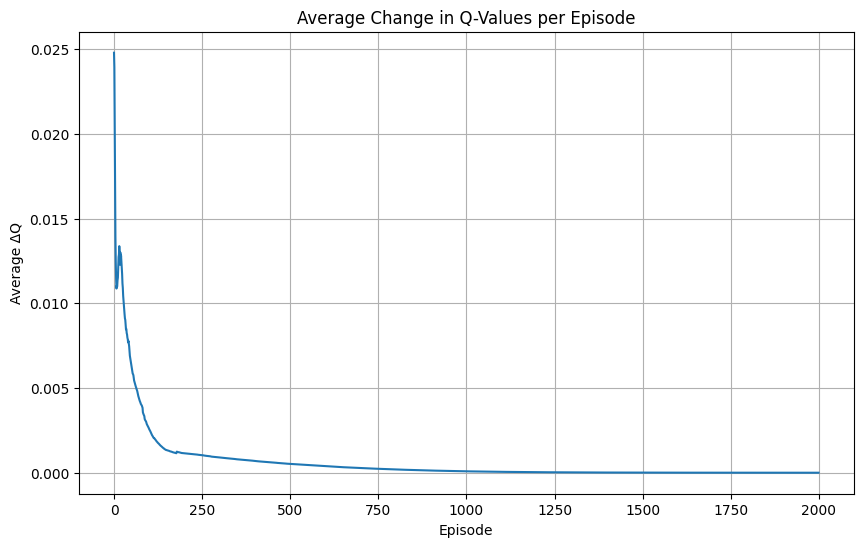

In [5]:
average_delta_per_episode = []
for i in range(num_episodes):
    episode_deltas = [delta_q[(t, c, a)][i] for (t, c, a) in delta_q.keys() if i < len(delta_q[(t, c, a)])]
    if episode_deltas:
        average_delta_per_episode.append(sum(episode_deltas) / len(episode_deltas))
    else:
        average_delta_per_episode.append(0)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(average_delta_per_episode)
plt.title('Average Change in Q-Values per Episode')
plt.xlabel('Episode')
plt.ylabel('Average ΔQ')
plt.grid(True)
plt.show()



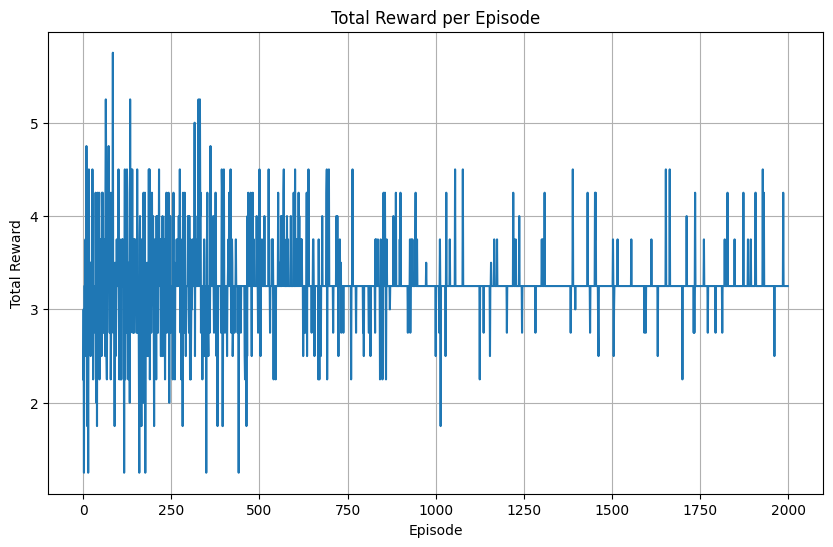

In [6]:
# Plot the rewards
plt.figure(figsize=(10, 6))
plt.plot(episode_rewards)
plt.title('Total Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()

In [7]:
q_table.get_best_route(7)

[(0, 7, Action(type=<ActionType.SWITCH: 0.5>, channel_index=0)),
 (1, 0, Action(type=<ActionType.SWITCH: 0.5>, channel_index=1)),
 (2, 1, Action(type=<ActionType.SWITCH: 0.5>, channel_index=0)),
 (3, 0, Action(type=<ActionType.SWITCH: 0.5>, channel_index=1)),
 (4, 1, Action(type=<ActionType.SWITCH: 0.5>, channel_index=7)),
 (5, 7, Action(type=<ActionType.SWITCH: 0.5>, channel_index=1)),
 (6, 1, Action(type=<ActionType.SWITCH: 0.5>, channel_index=2)),
 (7, 2, Action(type=<ActionType.SWITCH: 0.5>, channel_index=0)),
 (8, 0, Action(type=<ActionType.SWITCH: 0.5>, channel_index=7))]